In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/working'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
"""
f='/kaggle/working/dc_02_false_1_true'
s='/kaggle/working/dc_02_true_1_true'
t='/kaggle/working/dc_02_false_095_true'
y='/kaggle/working/dc_02_true_095_true'
os.makedirs(f)
os.makedirs(s)
os.makedirs(t)
os.makedirs(y)
"""
os.makedirs('/kaggle/working/models')

In [2]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import MNIST, CIFAR10
from IPython.display import Image
from torchvision.utils import save_image
import os
%matplotlib inline
plt.style.use("ggplot")

class CFG:
    batch_size = 128
    num_epochs = 30
    workers = 4
    seed = 2021
    image_size = 64
    download = True
    dataroot = "data"
    nc = 3  ## number of chanels
    ngf = 64  # Size of feature maps in generator
    nz = 100  # latent random input vector
    ndf = 64  # Size of feature maps in discriminator
    lr = 0.0002
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sample_dir = "./images/"


if not os.path.exists(CFG.sample_dir):
    os.makedirs(CFG.sample_dir)

cifar_dataset = CIFAR10(
    root=CFG.dataroot,
    download=CFG.download,
    transform=transforms.Compose(
        [
            transforms.Resize([CFG.image_size, CFG.image_size]),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    ),
)

Files already downloaded and verified


Label:  6


(array([ 140.,  578., 1378., 1406., 1163., 1691., 1246., 1402., 1351.,
         602.,  440.,  344.,  279.,  185.,   83.]),
 array([-0.99215686, -0.86091501, -0.72967321, -0.59843135, -0.46718955,
        -0.33594772, -0.20470588, -0.07346405,  0.05777778,  0.18901961,
         0.32026145,  0.45150328,  0.58274508,  0.71398693,  0.84522873,
         0.97647059]),
 <BarContainer object of 15 artists>)

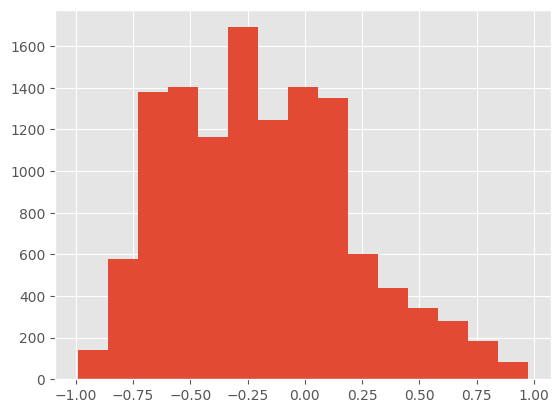

In [3]:
img, label = cifar_dataset[0]
print("Label: ", label)
plt.hist(img[:, :, :].flatten(), bins=15)

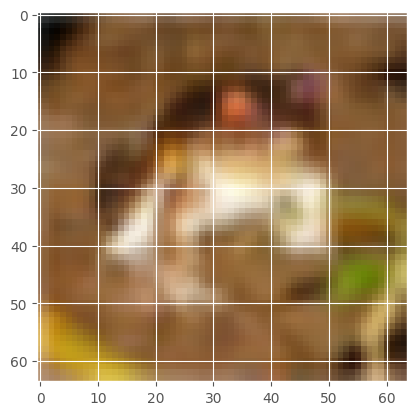

In [4]:
# unnormalization image from range (-1)-1 to range 0-1 to display it
def denorm(img):
    # write your code
    return (img + 1) / 2

# show  image sample with matplotlib
import matplotlib.pyplot as plt
plt.imshow(denorm(img).permute((1, 2, 0)))

In [6]:
data_loader = torch.utils.data.DataLoader(cifar_dataset, batch_size=CFG.batch_size, shuffle=True, drop_last=True, num_workers=CFG.workers)

In [9]:
import torch
from torch.optim.optimizer import Optimizer, required

from torch.autograd import Variable
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from torch.nn import Parameter

def l2normalize(v, eps=1e-12):
    return v / (v.norm() + eps)


class SpectralNorm(nn.Module):
    def __init__(self, module, name='weight', power_iterations=1):
        super(SpectralNorm, self).__init__()
        self.module = module
        self.name = name
        self.power_iterations = power_iterations
        if not self._made_params():
            self._make_params()

    def _update_u_v(self):
        u = getattr(self.module, self.name + "_u")
        v = getattr(self.module, self.name + "_v")
        w = getattr(self.module, self.name + "_bar")

        height = w.data.shape[0]
        for _ in range(self.power_iterations):
            v.data = l2normalize(torch.mv(torch.t(w.view(height,-1).data), u.data))
            u.data = l2normalize(torch.mv(w.view(height,-1).data, v.data))

        # sigma = torch.dot(u.data, torch.mv(w.view(height,-1).data, v.data))
        sigma = u.dot(w.view(height, -1).mv(v))
        setattr(self.module, self.name, w / sigma.expand_as(w))

    def _made_params(self):
        try:
            u = getattr(self.module, self.name + "_u")
            v = getattr(self.module, self.name + "_v")
            w = getattr(self.module, self.name + "_bar")
            return True
        except AttributeError:
            return False


    def _make_params(self):
        w = getattr(self.module, self.name)

        height = w.data.shape[0]
        width = w.view(height, -1).data.shape[1]

        u = Parameter(w.data.new(height).normal_(0, 1), requires_grad=False)
        v = Parameter(w.data.new(width).normal_(0, 1), requires_grad=False)
        u.data = l2normalize(u.data)
        v.data = l2normalize(v.data)
        w_bar = Parameter(w.data)

        del self.module._parameters[self.name]

        self.module.register_parameter(self.name + "_u", u)
        self.module.register_parameter(self.name + "_v", v)
        self.module.register_parameter(self.name + "_bar", w_bar)


    def forward(self, *args):
        self._update_u_v()
        return self.module.forward(*args)

In [10]:
import torch.nn as nn
# Generator
class Generator(nn.Module):
    def __init__(self, nc, nz, ngf):
        super(Generator, self).__init__()
        # ConvTranspose2d nz ngf * 8
        # BatchNorm2d
        # ReLU
        
        # ConvTranspose2d ngf * 8 ngf * 4
        # BatchNorm2d
        # ReLU
        
        # ConvTranspose2d ngf * 4 ngf * 2
        # BatchNorm2d
        # ReLU
        
        # ConvTranspose2d ngf * 2 ngf
        # BatchNorm2d
        # ReLU
        
        # ConvTranspose2d ngf  nc
        # Sigmoid
        """
        self.blocks = nn.Sequential(
            nn.ConvTranspose2d(in_channels=nz, out_channels=ngf * 16, kernel_size=(4, 4), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 16, out_channels=ngf * 8, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 8, out_channels=ngf * 4, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(0.2),

            nn.ConvTranspose2d(in_channels=ngf * 4, out_channels=ngf * 2, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 2, out_channels=ngf, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(0.2),
            nn.Conv2d(in_channels=ngf, out_channels=nc, kernel_size=(3, 3), padding=1),
            nn.Tanh()
        )
        
        """
        self.blocks = nn.Sequential(
            nn.ConvTranspose2d(in_channels=nz, out_channels=ngf * 16, kernel_size=(4, 4), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 16, out_channels=ngf * 8, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 8, out_channels=ngf * 4, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(0.2),

            nn.ConvTranspose2d(in_channels=ngf * 4, out_channels=ngf * 2, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 2, out_channels=ngf, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(0.2),
            nn.Conv2d(in_channels=ngf, out_channels=nc, kernel_size=(3, 3), padding=1),
            nn.Tanh()
            #nn.Sigmoid()
        )
        
    

    def forward(self, input):
        input = input.view(input.shape[0], input.shape[1], 1, 1)
        input = self.blocks(input)
        return input
        #return self.blocks(input)
        #return self.model(input).flatten()

# Discriminator

class Discriminator(nn.Module):
    def __init__(self, nc, ndf, uses_spectralNorm, dropout_rate):
        super(Discriminator, self).__init__()
        self.uses_spectralNorm = uses_spectralNorm
        self.dropout_rate = dropout_rate
        # SpectralNorm Conv2d
        # LeakyReLU
    
        # SpectralNorm Conv2d
        # BatchNorm2d
        # LeakyReLU
    
        # SpectralNorm Conv2d
        # BatchNorm2d
        # LeakyReLU
    
        # SpectralNorm Conv2d
        # BatchNorm2d
        # LeakyReLU
    
        # SpectralNorm Conv2d
        # Sigmoid
        self.blocks = nn.Sequential(
            self.spectralNormOrWithoutFun(in_channels=nc, out_channels=ndf, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            self.spectralNormOrWithoutFun(in_channels=ndf, out_channels=ndf * 2, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            self.spectralNormOrWithoutFun(in_channels=ndf * 2, out_channels=ndf * 4, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            self.spectralNormOrWithoutFun(in_channels=ndf * 4, out_channels=ndf * 8, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            self.spectralNormOrWithoutFun(in_channels=ndf * 8, out_channels=1, kernel_size=(4, 4),stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, input):
        input = self.blocks(input)
        return input.view(input.shape[0], 1)
        #return self.blocks(input).flatten()


    def spectralNormOrWithoutFun(self, in_channels, out_channels, kernel_size, stride, padding, bias):
        conv2d = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias)
        if self.uses_spectralNorm:
            return SpectralNorm(conv2d)
        else:
            return conv2d

In [14]:
def initialize_weights(model):
    classname = model.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

In [15]:
DCG = Generator(CFG.nc, CFG.nz, CFG.ngf)

# create new Discriminator model

# DCD = DCDiscriminator...
DCD = Discriminator(CFG.nc, CFG.ndf,False, 0.2)
a=torch.randn(2, CFG.nz)
#a=torch.randn(2, CFG.nz, 1, 1)
print(a.shape)
X = DCG(torch.randn(2, CFG.nz))
print(X.shape)
y = DCD(X)
print(y.shape)

torch.Size([2, 100])
torch.Size([2, 3, 64, 64])
torch.Size([2, 1])


In [16]:
drop_rate = 0

# dc_02_false_1_true
G_dc_02_false_1_true = Generator(CFG.nc, CFG.nz, CFG.ngf)
# create new Discriminator model
D_dc_02_false_1_true = Discriminator(CFG.nc, CFG.ndf,False, drop_rate)
label_smooth1 = 1.0
initialize_weights(G_dc_02_false_1_true)
initialize_weights(D_dc_02_false_1_true)

file_path = os.path.join('models', 'dc_02_false_1_true' + str(0) + '.pth')
torch.save(G_dc_02_false_1_true.state_dict(), file_path)#подправиь   

# dc_02_true_1_true
G_dc_02_true_1_true = Generator(CFG.nc, CFG.nz, CFG.ngf)
# create new Discriminator model
D_dc_02_true_1_true = Discriminator(CFG.nc, CFG.ndf,True, drop_rate)
label_smooth2 = 1.0
initialize_weights(G_dc_02_true_1_true)
initialize_weights(D_dc_02_true_1_true)

file_path = os.path.join('models', 'dc_02_true_1_true' + str(0) + '.pth')
torch.save(G_dc_02_true_1_true.state_dict(), file_path)#подправиь   

# dc_02_false_095_true
G_dc_02_false_095_true = Generator(CFG.nc, CFG.nz, CFG.ngf)
# create new Discriminator model
D_dc_02_false_095_true = Discriminator(CFG.nc, CFG.ndf,False, drop_rate)
label_smooth3 = 0.95
initialize_weights(G_dc_02_true_1_true)
initialize_weights(D_dc_02_true_1_true)

file_path = os.path.join('models', 'dc_02_false_095_true' + str(0) + '.pth')
torch.save(G_dc_02_false_095_true.state_dict(), file_path)#подправиь  

# dc_02_true_095_true
G_dc_02_true_095_true = Generator(CFG.nc, CFG.nz, CFG.ngf)
# create new Discriminator model
D_dc_02_true_095_true = Discriminator(CFG.nc, CFG.ndf,True, drop_rate)
label_smooth4 = 0.95
initialize_weights(D_dc_02_true_095_true)
initialize_weights(D_dc_02_true_095_true)

file_path = os.path.join('models', 'dc_02_true_095_true' + str(0) + '.pth')
torch.save(G_dc_02_true_095_true.state_dict(), file_path)#подправиь  



In [ ]:
# feel free to reuse your training functions

In [ ]:
# Label Smoothing, i.e. if you have two target labels: Real=1 and Fake=0, then for each incoming sample,
#  if it is real, then replace the label with a random number between 0.7 and 1.2, and
#  if it is a fake sample, replace it with 0.0 and 0.3 (for example).
#make the labels the noisy for the discriminator: occasionally flip the labels when training the discriminator

In [18]:
# define the criterion is nn.BCELoss()
loss_fn = nn.BCELoss()
## Define the optimizer for generator and discrimator lr=0.00023,

optimizer_generator1 = torch.optim.Adam(G_dc_02_false_1_true.parameters(), lr=0.00023, betas=(0.5, 0.999))
optimizer_discriminator1 = torch.optim.Adam(D_dc_02_false_1_true.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizer_generator2 = torch.optim.Adam(G_dc_02_true_1_true.parameters(), lr=0.00023, betas=(0.5, 0.999))
optimizer_discriminator2 = torch.optim.Adam(D_dc_02_true_1_true.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizer_generator3 = torch.optim.Adam(G_dc_02_false_095_true.parameters(), lr=0.00023, betas=(0.5, 0.999))
optimizer_discriminator3 = torch.optim.Adam(D_dc_02_false_095_true.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizer_generator4 = torch.optim.Adam(G_dc_02_true_095_true.parameters(), lr=0.00023, betas=(0.5, 0.999))
optimizer_discriminator4 = torch.optim.Adam(D_dc_02_true_095_true.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [19]:

#LABEL_SMOOTH = 0.95
def train_discriminator(D: nn.Module, G: nn.Module, images, D_optimizer: torch.optim.Optimizer, LABEL_SMOOTH,device):

    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(images.shape[0], 1).to(device)*LABEL_SMOOTH
    fake_labels = torch.ones(images.shape[0], 1).to(device)*(1- LABEL_SMOOTH)


    outputs = D(images)
    # Loss for real images
    real_score = outputs
    # Loss for fake images
    real_loss = loss_fn(real_score, real_labels)

    #z = torch.randn(CFG.batch_size, CFG.nz).to(device)
    z = torch.randn(CFG.batch_size, CFG.nz, 1, 1).to(CFG.device)
    fake_images = G(z)
    outputs = D(fake_images)
    
    d_loss_fake = loss_fn(outputs, fake_labels)
    fake_score = outputs

    # Sum losses
    d_loss = real_loss + d_loss_fake
    # Reset gradients
    D_optimizer.zero_grad()
    # Compute gradients
    d_loss.backward()

    # Adjust the parameters using backprop
    D_optimizer.step()
    
    return d_loss, real_score, fake_score

In [20]:
def train_generator(G: nn.Module, D: nn.Module, G_optimizer: torch.optim.Optimizer, use_noise, LABEL_SMOOTH,device):
    # Generate fake images and calculate loss
    # z = torch.randn(batch_size, latent_size).to(device)
    #z = np.random.normal(0, 1, (batch_size, latent_size))
    #z = torch.randn(CFG.batch_size, CFG.nz).to(device)
    z = np.random.normal(0, 1, (CFG.batch_size, CFG.nz, 1, 1))
    #print(f"The shape of the tensor is1: {z.shape}")

    if use_noise:
        noise = 0.005*np.random.uniform()*np.amax(z)
        z = z.astype('float64') + noise*np.random.normal(size=z.shape)
        z = torch.Tensor(z).to(device)
    else:
        z = torch.Tensor(z).to(device)

    #print(f"The shape of the tensor is1: {z.shape}")
    fake_images = G(z)

    fake_outputs = D(fake_images)
    labels = torch.ones(CFG.batch_size, 1).to(device)
    # calculate the generator loss
    g_loss = loss_fn(fake_outputs,labels)

    # Reset gradients
    G_optimizer.zero_grad()
    # Backprop and optimize
    g_loss.backward()
    G_optimizer.step()
    return g_loss, fake_images

In [22]:
def save_fake_images(G: nn.Module, dir, index,device):
    # sample_vectors = torch.randn(batch_size, latent_size).to(device)
    #z = np.random.normal(0, 1, (batch_size, latent_size))
    #z = torch.randn(CFG.batch_size, CFG.nz).to(device)
    z = np.random.normal(0, 1, (CFG.batch_size, CFG.nz, 1, 1))
    noise = 0.005*np.random.uniform()*np.amax(z)
    z = z.astype('float64') + noise*np.random.normal(size=z.shape)
    z = torch.Tensor(z).to(device)
    
    fake_images = G(z)
    #fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    fake_images = fake_images.view(fake_images.size(0), 3, 64, 64)
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    print('Saving', fake_fname)
    save_image(denorm(fake_images), os.path.join(CFG.sample_dir, dir+fake_fname), nrow=10)

In [24]:
#%%time
def train(G: nn.Module, D: nn.Module,G_optimizer: torch.optim.Optimizer,D_optimizer: torch.optim.Optimizer, LABEL_SMOOTH,use_noise, model_name):
    device = CFG.device
    num_epochs = CFG.num_epochs
    batch_size = CFG.batch_size
    
    total_step = len(data_loader)
    d_losses, g_losses, real_scores, fake_scores = [], [], [], []
    G.to(device)
    D.to(device)

    for epoch in range(num_epochs):
        for i, (images, _) in enumerate(data_loader):
            # Load a batch & transform to vectors
            #images = images.reshape(batch_size, -1).to(device)
            images = images.to(device)
            # Train the discriminator
            D.train()
            # Train the generator
            G.train()
            d_loss, real_score, fake_score = train_discriminator(D, G, images, D_optimizer, LABEL_SMOOTH,device)
            # Inspect the losses
            G.train()
            g_loss, fake_images = train_generator(G, D, G_optimizer, use_noise, LABEL_SMOOTH,device)
            if (i+1) % 200 == 0:
                d_losses.append(d_loss.item())
                g_losses.append(g_loss.item())
                real_scores.append(real_score.mean().item())
                fake_scores.append(fake_score.mean().item())
                print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                      .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(),
                              real_score.mean().item(), fake_score.mean().item()))
        # Sample and save images
        G.eval()
        save_fake_images(G, model_name, epoch+1,device)#подправить ?
        """
        if epoch % 5 == 0:
            file_path = os.path.join('models', model_name + str(epoch) + '.pth')
            torch.save(G.state_dict(), file_path)#подправиь
        """
        file_path = os.path.join('models', model_name + str(epoch) + '.pth')
        torch.save(G.state_dict(), file_path)#подправиь   

    return d_losses, g_losses, real_scores,fake_scores

In [25]:
#dc_02_false_1_true
d_losses, g_losses, real_scores,fake_scores = train(G_dc_02_false_1_true , D_dc_02_false_1_true,optimizer_generator1,optimizer_discriminator1 , label_smooth1,True, "dc_02_false_1_true")


Epoch [0/30], Step [200/390], d_loss: 1.1619, g_loss: 1.0252, D(x): 0.51, D(G(z)): 0.32
Saving fake_images-0001.png
Epoch [1/30], Step [200/390], d_loss: 1.1113, g_loss: 2.4762, D(x): 0.70, D(G(z)): 0.47
Saving fake_images-0002.png
Epoch [2/30], Step [200/390], d_loss: 1.1745, g_loss: 1.4512, D(x): 0.69, D(G(z)): 0.51
Saving fake_images-0003.png
Epoch [3/30], Step [200/390], d_loss: 1.3236, g_loss: 2.2676, D(x): 0.72, D(G(z)): 0.59
Saving fake_images-0004.png
Epoch [4/30], Step [200/390], d_loss: 1.3908, g_loss: 1.6122, D(x): 0.63, D(G(z)): 0.56
Saving fake_images-0005.png
Epoch [5/30], Step [200/390], d_loss: 1.1876, g_loss: 1.6358, D(x): 0.47, D(G(z)): 0.29
Saving fake_images-0006.png
Epoch [6/30], Step [200/390], d_loss: 1.6116, g_loss: 0.7754, D(x): 0.25, D(G(z)): 0.08
Saving fake_images-0007.png
Epoch [7/30], Step [200/390], d_loss: 1.0440, g_loss: 1.7447, D(x): 0.53, D(G(z)): 0.29
Saving fake_images-0008.png
Epoch [8/30], Step [200/390], d_loss: 1.2800, g_loss: 1.7080, D(x): 0.66

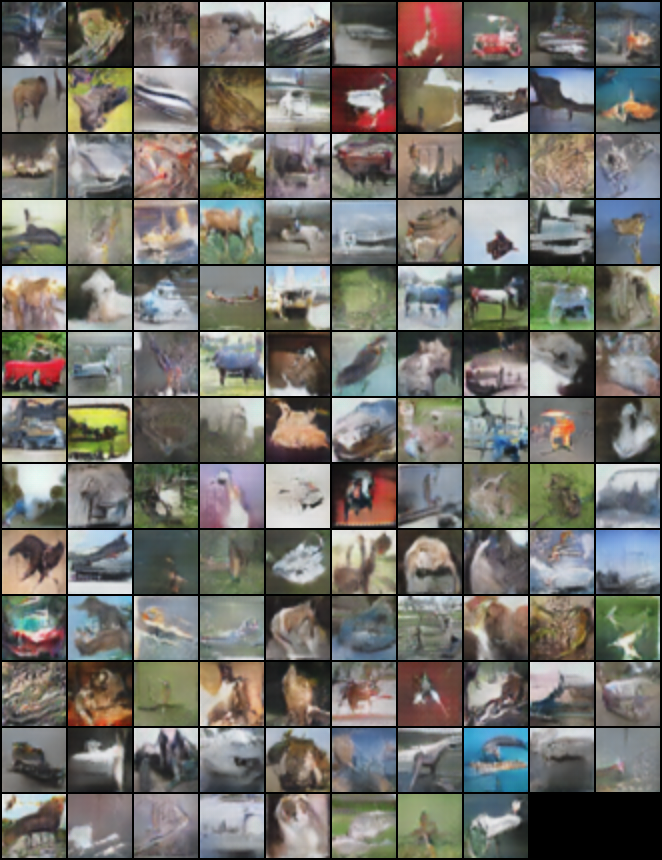

In [28]:
Image(os.path.join(CFG.sample_dir, 'dc_02_false_1_truefake_images-0030.png'))

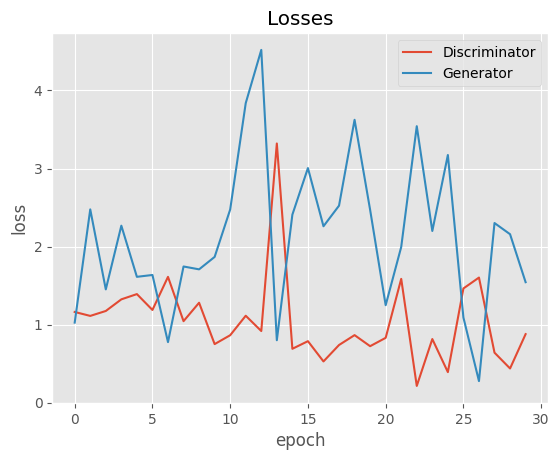

In [29]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

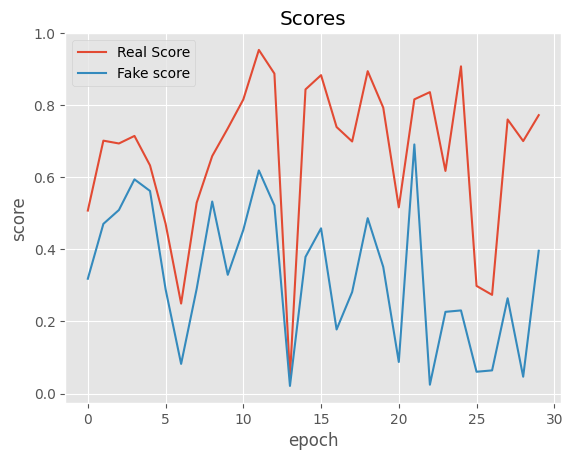

In [30]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

In [31]:
d_losses, g_losses, real_scores,fake_scores = train(G_dc_02_true_1_true , D_dc_02_true_1_true,optimizer_generator2,optimizer_discriminator2 , label_smooth2,True, "dc_02_true_1_true")


Epoch [0/30], Step [200/390], d_loss: 0.9968, g_loss: 3.8667, D(x): 0.69, D(G(z)): 0.40
Saving fake_images-0001.png
Epoch [1/30], Step [200/390], d_loss: 1.0075, g_loss: 1.7838, D(x): 0.61, D(G(z)): 0.35
Saving fake_images-0002.png
Epoch [2/30], Step [200/390], d_loss: 1.2291, g_loss: 1.5183, D(x): 0.46, D(G(z)): 0.28
Saving fake_images-0003.png
Epoch [3/30], Step [200/390], d_loss: 1.0495, g_loss: 1.0757, D(x): 0.50, D(G(z)): 0.25
Saving fake_images-0004.png
Epoch [4/30], Step [200/390], d_loss: 1.0990, g_loss: 1.8006, D(x): 0.63, D(G(z)): 0.43
Saving fake_images-0005.png
Epoch [5/30], Step [200/390], d_loss: 1.0980, g_loss: 1.5858, D(x): 0.63, D(G(z)): 0.44
Saving fake_images-0006.png
Epoch [6/30], Step [200/390], d_loss: 1.7622, g_loss: 0.8246, D(x): 0.22, D(G(z)): 0.10
Saving fake_images-0007.png
Epoch [7/30], Step [200/390], d_loss: 0.9423, g_loss: 2.0929, D(x): 0.79, D(G(z)): 0.48
Saving fake_images-0008.png
Epoch [8/30], Step [200/390], d_loss: 1.2047, g_loss: 0.9789, D(x): 0.45

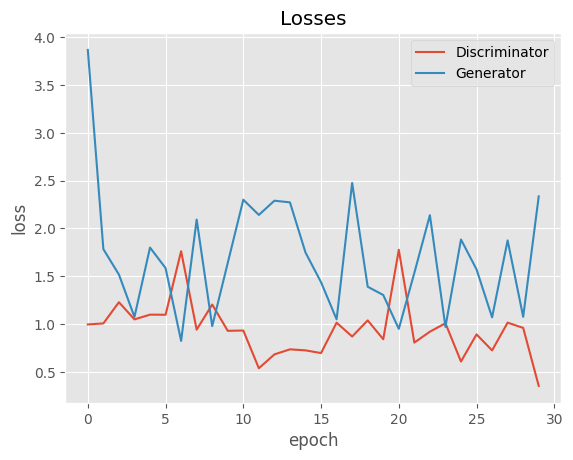

In [32]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

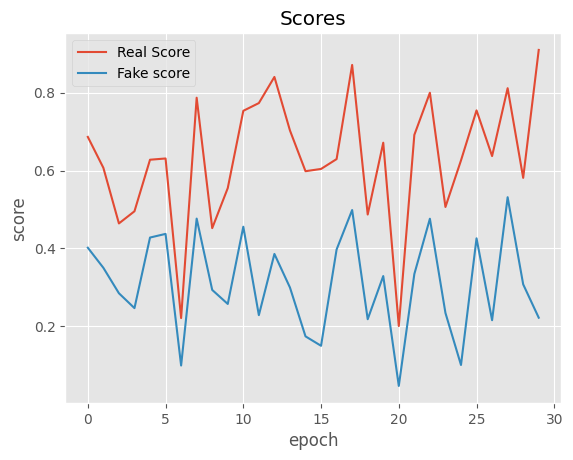

In [33]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

In [34]:
d_losses, g_losses, real_scores,fake_scores = train(G_dc_02_false_095_true , D_dc_02_false_095_true,optimizer_generator3,optimizer_discriminator3 , label_smooth3,True,  "dc_02_false_095_true")


Epoch [0/30], Step [200/390], d_loss: 1.2472, g_loss: 1.1793, D(x): 0.63, D(G(z)): 0.51
Saving fake_images-0001.png
Epoch [1/30], Step [200/390], d_loss: 1.3630, g_loss: 2.7863, D(x): 0.63, D(G(z)): 0.56
Saving fake_images-0002.png
Epoch [2/30], Step [200/390], d_loss: 1.1309, g_loss: 1.6811, D(x): 0.62, D(G(z)): 0.40
Saving fake_images-0003.png
Epoch [3/30], Step [200/390], d_loss: 1.2435, g_loss: 0.9405, D(x): 0.44, D(G(z)): 0.27
Saving fake_images-0004.png
Epoch [4/30], Step [200/390], d_loss: 1.0791, g_loss: 1.2380, D(x): 0.53, D(G(z)): 0.28
Saving fake_images-0005.png
Epoch [5/30], Step [200/390], d_loss: 1.0319, g_loss: 0.8891, D(x): 0.49, D(G(z)): 0.17
Saving fake_images-0006.png
Epoch [6/30], Step [200/390], d_loss: 1.0928, g_loss: 1.3862, D(x): 0.61, D(G(z)): 0.40
Saving fake_images-0007.png
Epoch [7/30], Step [200/390], d_loss: 1.1656, g_loss: 1.5313, D(x): 0.60, D(G(z)): 0.44
Saving fake_images-0008.png
Epoch [8/30], Step [200/390], d_loss: 0.8666, g_loss: 1.5838, D(x): 0.65

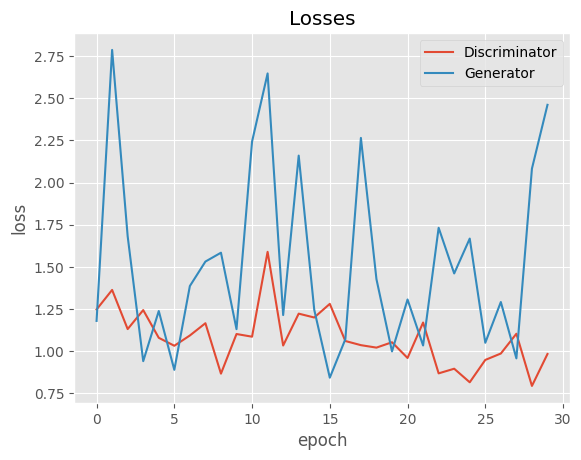

In [35]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

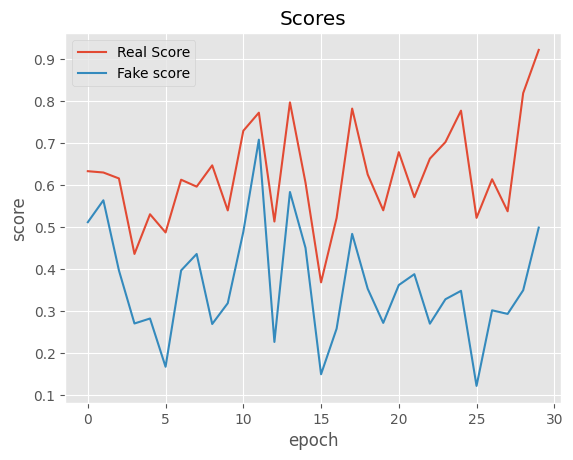

In [36]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

In [37]:
d_losses, g_losses, real_scores,fake_scores = train(G_dc_02_true_095_true , D_dc_02_true_095_true,optimizer_generator4,optimizer_discriminator4 , label_smooth4,True, "dc_02_true_095_true")

Epoch [0/30], Step [200/390], d_loss: 1.5649, g_loss: 1.6798, D(x): 0.64, D(G(z)): 0.61
Saving fake_images-0001.png
Epoch [1/30], Step [200/390], d_loss: 1.3436, g_loss: 1.0780, D(x): 0.50, D(G(z)): 0.42
Saving fake_images-0002.png
Epoch [2/30], Step [200/390], d_loss: 1.2949, g_loss: 2.0682, D(x): 0.75, D(G(z)): 0.58
Saving fake_images-0003.png
Epoch [3/30], Step [200/390], d_loss: 1.2385, g_loss: 0.8436, D(x): 0.45, D(G(z)): 0.27
Saving fake_images-0004.png
Epoch [4/30], Step [200/390], d_loss: 1.2104, g_loss: 2.2084, D(x): 0.66, D(G(z)): 0.49
Saving fake_images-0005.png
Epoch [5/30], Step [200/390], d_loss: 1.2837, g_loss: 2.6302, D(x): 0.86, D(G(z)): 0.63
Saving fake_images-0006.png
Epoch [6/30], Step [200/390], d_loss: 0.9836, g_loss: 1.5991, D(x): 0.59, D(G(z)): 0.30
Saving fake_images-0007.png
Epoch [7/30], Step [200/390], d_loss: 1.3625, g_loss: 1.5330, D(x): 0.69, D(G(z)): 0.59
Saving fake_images-0008.png
Epoch [8/30], Step [200/390], d_loss: 1.2779, g_loss: 0.7774, D(x): 0.41

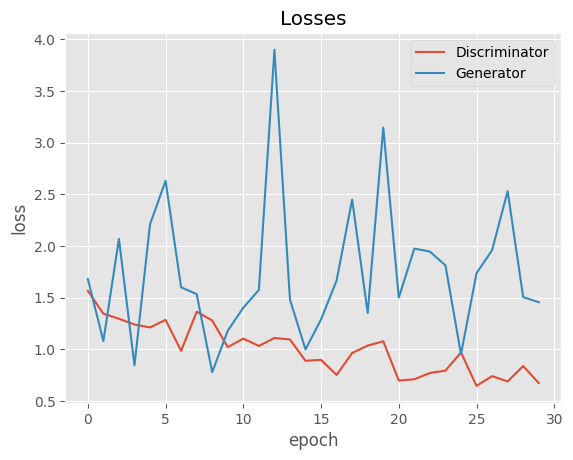

In [38]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

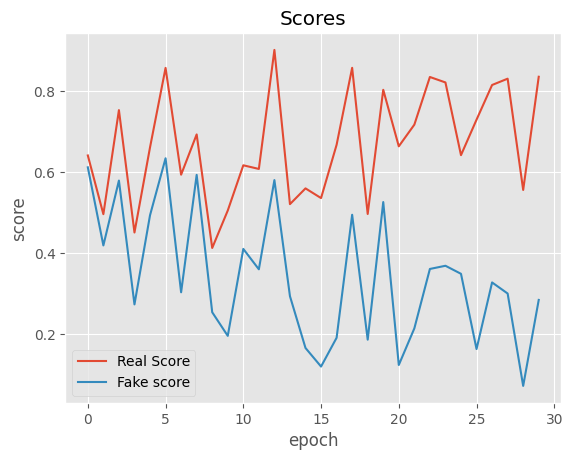

In [39]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

In [42]:
!zip -r file.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/images/ (stored 0%)
  adding: kaggle/working/images/dc_02_false_095_truefake_images-0026.png (deflated 0%)
  adding: kaggle/working/images/dc_02_false_095_truefake_images-0027.png (deflated 0%)
  adding: kaggle/working/images/dc_02_false_095_truefake_images-0014.png (deflated 0%)
  adding: kaggle/working/images/dc_02_false_1_truefake_images-0024.png (deflated 0%)
  adding: kaggle/working/images/dc_02_true_095_truefake_images-0028.png (deflated 0%)
  adding: kaggle/working/images/dc_02_false_1_truefake_images-0005.png (deflated 0%)
  adding: kaggle/working/images/dc_02_false_1_truefake_images-0010.png (deflated 0%)
  adding: kaggle/working/images/dc_02_true_095_truefake_images-0011.png (deflated 0%)
  adding: kaggle/working/images/dc_02_true_095_truefake_images-0015.png (deflated 0%)
  adding: kaggle/working/images/dc_02_true_1_truefake_images-0029.png (deflated 0%)
  adding: kaggle/working/images/dc_02_true_1_truefake_image

In [43]:
from IPython.display import FileLink
FileLink(r'file.zip')

/kaggle/working/file.zip

In [11]:
# clone is repo: https://github.com/w86763777/pytorch-gan-metrics.git and install pytorch-gan-metrics
#!git clone https://github.com/w86763777/pytorch-gan-metrics.git
!pip install pytorch-gan-metrics

In [22]:
%cd pytorch_gan_metrics

[Errno 2] No such file or directory: 'pytorch_gan_metrics'
/kaggle/working


In [12]:
 # import function from pytorch_gan_metrics
#from pytorch_gan_metrics.utils import calc_and_save_stats
from pytorch_image_generation_metrics  import (get_inception_score,
                                 get_fid,
                                 get_inception_score_and_fid)

# create the Generator Dataset. returns the image, generated from the Generator network
class GeneratorDataset(torch.utils.data.Dataset):
    def __init__(self, G, z_dim):
        self.G = G
        self.z_dim = z_dim

    def __len__(self):
        return 1000

    def __getitem__(self, index):
        return self.G(torch.randn(1, self.z_dim, 1, 1).cuda())[0]

# define dataset
#create dataloader

# Inception Score
# Frechet Inception Distance
# Inception Score + Frechet Inception Distance

In [16]:
 # import function from pytorch_gan_metrics
from pytorch_image_generation_metrics  import (get_inception_score,
                                 get_fid,
                                 get_inception_score_and_fid)

# create the Generator Dataset. returns the image, generated from the Generator network
class GeneratorDataset(torch.utils.data.Dataset):
    def __init__(self, G, z_dim, num_samples=1000):
        self.G = G.eval() 
        self.z_dim = z_dim
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        with torch.no_grad():  # Отключаем градиенты для генерации
            z = torch.randn(1, self.z_dim, 1, 1).cuda()  # Латентный вектор
            img = self.G(z)[0]  # Генерация изображения
            img = (img + 1) / 2
            return img


In [19]:
all_models = [
    "dc_02_false_1_true",
    "dc_02_true_1_true",
    "dc_02_false_095_true",
    "dc_02_true_095_true"
]

In [20]:
colors={
    'dc_02_false_1_true': 'gray',
    'dc_02_true_1_true': 'blue',
    'dc_02_false_095_true': 'green',
    'dc_02_true_095_true': 'red'
}
legend=[
    'DCGan (uses noise and dropout)',
    'Spectral Norm',
    'Label Smoothing',
    'Label Smoothing + Spectral Norm'
]
#epochs=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

#epochs=[0, 5, 10, 15, 20, 25,29]
#epochs=[0, 5,10]
epochs=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19 ,20,21,22,23,24,25,26,27,28,29]

In [22]:
real_stats_path = "/kaggle/input/modelgan2/lb gan 2 verison/cifar10.train.npz"
dir_model ='/kaggle/input/modelgan2/lb gan 2 verison/models/'

In [19]:
import os.path
os.path.isfile(real_stats_path)

True

In [23]:
inception_score_array=[]
inception_score_std_array=[]
fid_array=[]
epochs_array=[]

num_samples = 1000

for name in all_models:    
    inception_score_array_t=[]
    inception_score_std_array_t=[]
    fid_array_t=[]
    epochs_array_t=[]
    print('model '+name)
    for i in epochs:
        #full_name = CFG.dataroot + name + str(i)
        full_name = dir_model + name + str(i)
        G_model = Generator(CFG.nc, CFG.nz, CFG.ngf)
        G_model.load_state_dict(torch.load(full_name+'.pth', weights_only=False))
        #G_model.to(CFG.device)
        G_model = G_model.cuda()  # Перенос на GPU, если доступно
        G_model.eval() 
                
        # define dataset
        g_dataset = GeneratorDataset(G_model, CFG.nz,num_samples)
        # create dataloader
        g_loader = torch.utils.data.DataLoader(
            g_dataset, 
            CFG.batch_size,
            shuffle=False,
            num_workers=0
        )
        #print(g_loader.dataset.__len__)
        #print(real_stats_path)
        (inception_score, inception_score_std), fid = get_inception_score_and_fid(g_loader, real_stats_path)
        #inception_score, inception_score_std = get_inception_score(g_loader, real_stats_path)
        print(f"Inception Score: {inception_score}\nFID: {fid}\nEpoch: {i}")
        inception_score_array_t.append(inception_score)
        inception_score_std_array_t.append(inception_score_std)
        fid_array_t.append(fid)
        epochs_array_t.append(i)
    
    inception_score_array.append(inception_score_array_t)
    inception_score_std_array.append(inception_score_std_array_t)
    fid_array.append(fid_array_t)
    epochs_array.append(epochs_array_t)

model dc_02_false_1_true


Downloading: "https://github.com/w86763777/pytorch-image-generation-metrics/releases/download/v0.1.0/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 69.7MB/s]


Inception Score: 1.7294804883487518
FID: 315.30546669503957
Epoch: 0
Inception Score: 2.1256491215759317
FID: 329.5436483609847
Epoch: 1
Inception Score: 2.407977158951996
FID: 249.5807845787642
Epoch: 2
Inception Score: 2.6648075033018217
FID: 266.0106541528611
Epoch: 3
Inception Score: 2.5650931968973305
FID: 223.01696148671567
Epoch: 4
Inception Score: 3.6165123391818903
FID: 184.68686808071874
Epoch: 5
Inception Score: 3.7434993398360468
FID: 163.63475306535003
Epoch: 6
Inception Score: 3.9139246158141043
FID: 129.70171061995921
Epoch: 7
Inception Score: 3.210380864516567
FID: 152.6100714013532
Epoch: 8
Inception Score: 4.120805360831495
FID: 127.85095167996928
Epoch: 9
Inception Score: 4.029946413728349
FID: 136.86029472164068
Epoch: 10
Inception Score: 4.3866203990163255
FID: 114.51768354321882
Epoch: 11
Inception Score: 4.585722365538671
FID: 112.59766253443479
Epoch: 12
Inception Score: 5.104230963370214
FID: 103.3065208553644
Epoch: 13
Inception Score: 4.915622930305583
FID: 9

In [32]:
print(epochs_array)
print(inception_score_array)
print(fid_array)

[[0, 5, 10], [0, 5, 10], [0, 5, 10], [0, 5, 10]]
[[1.6795569227008027, 3.5407240539423577, 4.183447170652427], [1.6601578589571926, 3.197647802603648, 4.242318818884813], [1.4970587258811254, 2.9158506259555885, 4.548222216154887], [1.6150116195718909, 2.821363685188099, 4.283473137480593]]
[[313.07795877415447, 183.3618817872083, 136.40225102424773], [321.37473195991174, 190.98732851592328, 122.04096259074583], [330.38566899325025, 212.49579769964706, 113.53939708893506], [301.82737053519656, 193.7364728252092, 119.78567316236655]]


In [25]:
import pandas as pd

row_names = [
    'DCGan',
    'SN',
    'LS',
    'LS + SN'
]
df = pd.DataFrame(inception_score_array, columns=epochs, index=row_names)
pd.set_option('display.max_rows', None)  # Установить максимальное количество строк для отображения
pd.set_option('display.max_columns', None)  # Установить максимальное количество столбцов для отображе

# Выводим таблицу
print('--IS--')
print(df)

--IS--
               0         1         2         3         4         5         6   \
DCGan    1.729480  2.125649  2.407977  2.664808  2.565093  3.616512  3.743499   
SN       1.621808  2.252827  2.502452  2.381270  2.759668  3.249656  3.527193   
LS       1.506538  1.768399  2.968663  3.095234  2.464197  2.998772  3.524244   
LS + SN  1.647073  1.756537  2.812556  1.882823  3.093221  2.906033  3.126513   

               7         8         9         10        11        12        13  \
DCGan    3.913925  3.210381  4.120805  4.029946  4.386620  4.585722  5.104231   
SN       4.369422  3.329500  4.131419  4.493410  4.258099  4.672758  4.762484   
LS       3.917757  4.250056  4.161016  4.758542  4.438758  4.104823  4.899465   
LS + SN  3.382781  3.861920  4.008762  4.227756  4.380666  4.458136  4.327024   

               14        15        16        17        18        19        20  \
DCGan    4.915623  4.725394  4.612781  4.584715  4.853583  4.609862  4.709132   
SN       4.618576  

In [26]:
import pandas as pd

row_names = [
    'DCGan',
    'SN',
    'LS',
    'LS + SN'
]
df = pd.DataFrame(fid_array, columns=epochs, index=row_names)
pd.set_option('display.max_rows', None)  # Установить максимальное количество строк для отображения
pd.set_option('display.max_columns', None)  # Установить максимальное количество столбцов для отображе
# Выводим таблицу
print('--FID--')
print(df)

--FID--
                 0           1           2           3           4   \
DCGan    315.305467  329.543648  249.580785  266.010654  223.016961   
SN       322.444283  268.941729  275.900471  271.822065  240.841514   
LS       325.599116  299.452528  307.575032  237.881231  252.399938   
LS + SN  301.337530  264.773046  270.138445  273.627244  246.483325   

                 5           6           7           8           9   \
DCGan    184.686868  163.634753  129.701711  152.610071  127.850952   
SN       189.334653  165.000317  156.137263  171.198342  123.244934   
LS       214.718156  174.142709  166.482910  153.430000  136.738712   
LS + SN  192.593930  183.027353  158.647850  143.551993  128.537860   

                 10          11          12          13          14  \
DCGan    136.860295  114.517684  112.597663  103.306521   99.500216   
SN       121.309177  119.744790  107.806157  112.888806  121.486972   
LS       111.615363  107.680604  112.329801  108.782600   99.693914

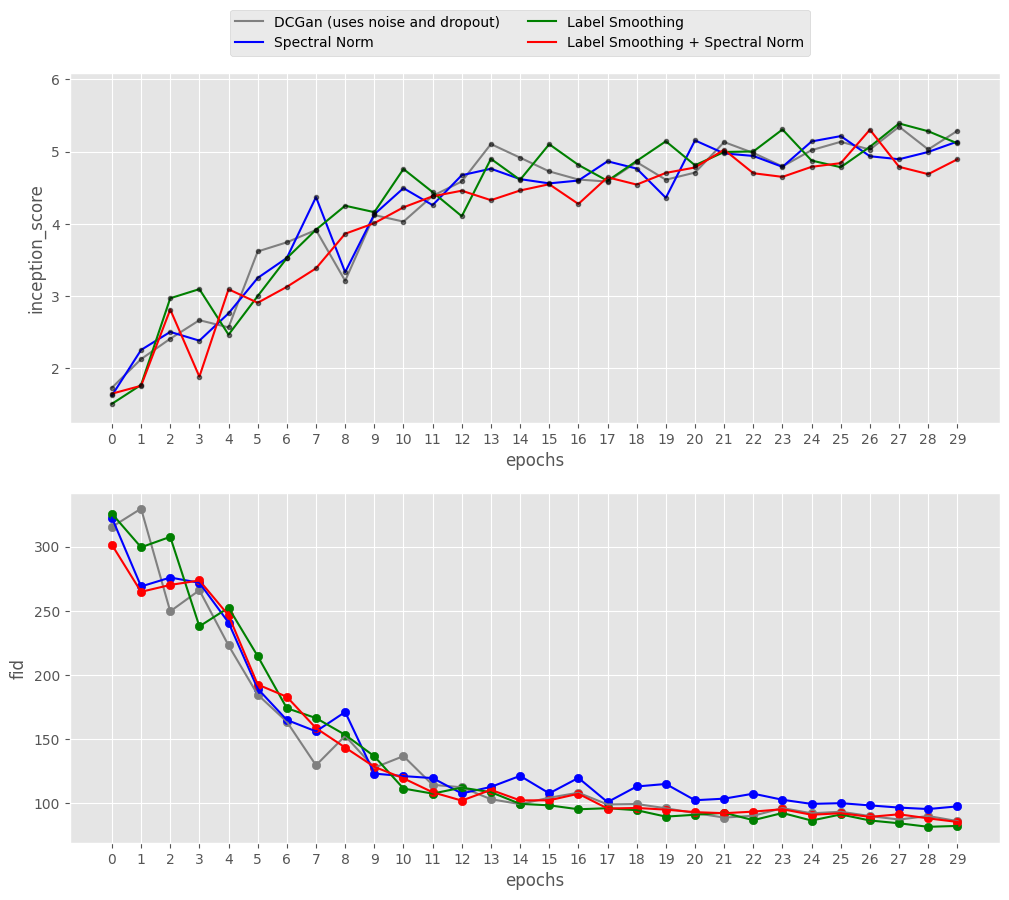

In [27]:
fig, axs = plt.subplots(2, figsize=(12, 10))

for i in range(len(all_models)):            
    name = all_models[i]
    axs[0].errorbar(x=epochs_array[i], 
                    y=inception_score_array[i], 
                    yerr=inception_score_std_array[i], 
                    fmt='.k', ecolor=colors[name], lw=0, alpha=0.5)
    axs[1].scatter(x=epochs_array[i], y=fid_array[i], c=colors[name])
    axs[0].plot(epochs_array[i], inception_score_array[i], c=colors[name])
    axs[1].plot(epochs_array[i], fid_array[i], c=colors[name])

axs[0].set_xticks(epochs)
axs[1].set_xticks(epochs)
axs[0].set_xlabel('epochs')
axs[0].set_ylabel('inception_score')
axs[1].set_xlabel('epochs')
axs[1].set_ylabel('fid')
fig.legend(legend, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)